## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Numerical Features Insights:

* **`longitude` / `latitude`**:
    * These features represent the geographical coordinates of the centroid for a specific area (likely a block group or residential neighborhood).
    * A standard deviation (`std`) of ~2, combined with the large difference between the `min` and `max` values (approx. 10 degrees), indicates that the analyzed areas are spread across a vast geographic surface, covering an entire state rather than just a single city or neighboring towns.

* **`housing_median_age`**:
    * Represents the median age of the houses in a specific location. The median is used instead of the arithmetic mean because it is robust and not sensitive to outliers.
    * The dataset includes highly diverse neighborhoods, ranging from newly built (1 year) to older ones (capped at 52 years), with the overall median age being around ~30 years.

* **`total_rooms`**:
    * Represents the total number of rooms across all housing units in a given area (block group).
    * The data ranges from areas with very few rooms (e.g., isolated or mountainous regions) to metropolitan zones reaching up to 39,000+ rooms. Because the `mean > median`, we can conclude that the `total_rooms` feature has a right-skewed distribution (Positive Skew).

* **`total_bedrooms` / `population`**:
    * Represent the total number of bedrooms and the total number of inhabitants within the area specified by the coordinates.
    * Similar to `total_rooms`, the conclusions are identical: these features also exhibit a positive skew, meaning a few highly dense outliers push the average up.

* **`households`**:
    * Represents the total number of households (groups of people living together in the same unit) within a specific area.

* **`median_income`**:
    * The cumulative annual income of a household, scaled down for easier data processing (e.g., a value of 1.5 represents $15,000 per year). It is capped at 15.0001 (approx. $150,000).
    * This shows that the data captures a highly diverse population across California at the time of the census, reflecting various social classes and socioeconomic backgrounds (from disadvantaged communities to luxury neighborhoods).

* **`median_house_value`**:
    * This is the target variable (the most important column for our goal), which we will need to predict using a regression model. It represents the median price/value of a home in a given area.


In [ ]:

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Note on Missing Data:

* Overall, the dataset is clean, except for the `total_bedrooms` column, which contains 207 `null` values. 
* **Crucial distinction:** A `null` value does not mean there are "zero bedrooms" (if it were a purely commercial zone, the value would be recorded as `0`). It simply means the data is missing (e.g., lost during collection or unrecorded).
* **Next steps:** Since 207 rows represent exactly **1%** of the dataset (20,640 entries), we have two safe strategies to handle this later:
    1.  **Drop the rows:** Acceptable, as the data loss is minimal.
    2.  **Fill with the median (Imputation):** The recommended best practice. This allows us to keep the other valuable features (income, location, age) of those 207 areas intact.


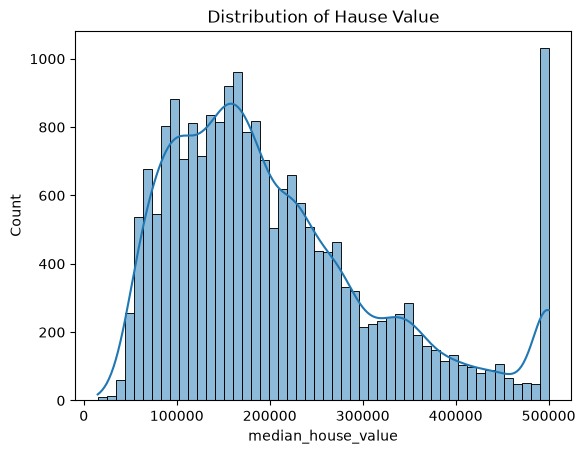

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Hause Value')
plt.show()

## Conclusion :

Observing the histogram, most values are concentrated in the 50000 - 250000 range, but the right tail unnaturally explodes at the 500000 mark. This massive spike represents artificially capped data, meaning any house worth more than this limit was simply recorded as the maximum value. Applying a log transformation will not solve this problem, as the artificial cluster will merely shift to a different scale. If we keep these capped values, it will negatively affect the model during training, because the coefficients will be tempted to learn these artificial limits, distorting the predictions for regular houses. A proper treatment for this issue is to completely drop the examples that hit this capped threshold, sacrificing a small percentage of data to ensure the model learns a clean and accurate relationship for the rest of the homes.


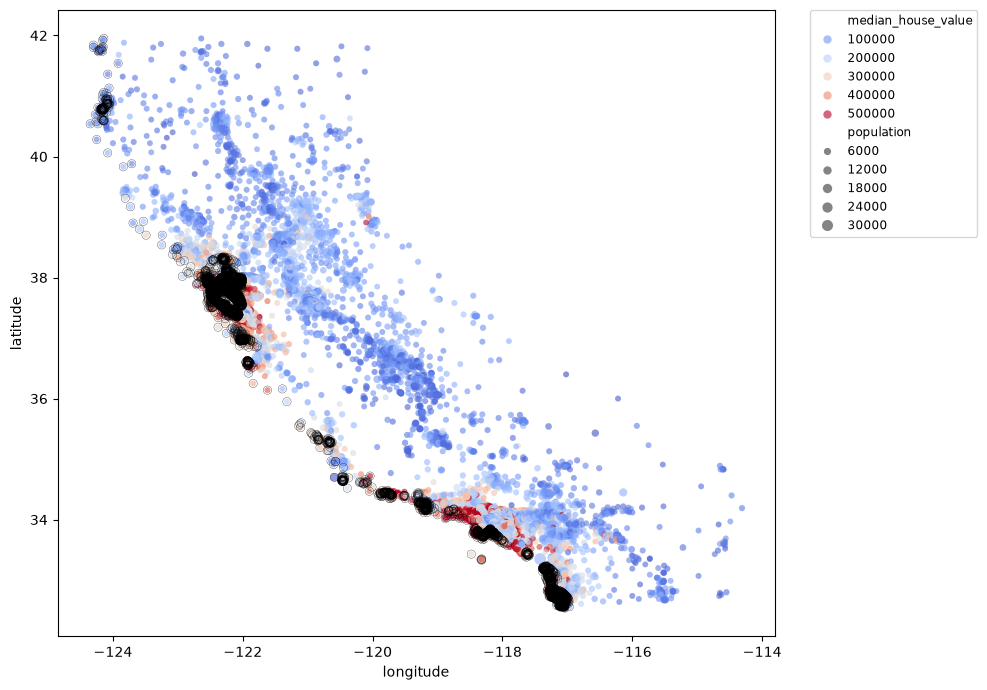

In [29]:
# Set up the figure space
plt.figure(figsize=(10, 7))

# 1. Base Scatterplot: All points, colored by price, sized by population
base_scatter = sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    size='population',
    palette='coolwarm',
    alpha=0.6,          
    linewidth=0          # No border for standard points
)

# Filter the dataset for locations near the water
# Adjust these categories based on the exact strings in your 'ocean_proximity' column
water_locations = df[df['ocean_proximity'].isin(['NEAR OCEAN', 'NEAR BAY', 'ISLAND'])]

# 2. Highlight Layer: Draw only the borders for the filtered points
sns.scatterplot(
    data=water_locations,
    x='longitude',
    y='latitude',
    facecolor='none',    # Transparent center
    edgecolor='black',   # Highlight border color
    linewidth=0.2,       # Border thickness
    ax=base_scatter.axes # Force it to draw on top of the first map
)

# 3. Customize and move the legend OUTSIDE the plot area
plt.legend(
    bbox_to_anchor=(1.05, 1), # Moves legend to the right, outside the frame
    loc='upper left',
    borderaxespad=0,
    fontsize='small',         # Make the text slightly smaller
    title_fontsize='medium'
)

# Adjust layout to ensure the external legend is not cut off by the window
plt.tight_layout()
plt.show()

## Conclusion:

This scatter plot acts as a geographical map of the block group centroids across California. The visual clearly demonstrates the profound impact of location on real estate prices:

* **Coastal Wealth (Red Clusters):** The red points (indicating high `median_house_value`) are heavily concentrated near the ocean (highlighted with black borders). This aligns with economic reality, as coastal regions developed into massive economic hubs with more possibilities (tourism, naval transport, tech industries), driving up demand and prices.
* **Major Metropolitan Hubs:** The high prices are not uniformly distributed along the entire coast but are clustered in two major distinct areas: the Bay Area (San Francisco) in the north and the Los Angeles/San Diego region in the south.
* **Inland Contrast:** Moving inland, away from the coastal black-bordered points, the map becomes predominantly blue. This massive inland area highlights a sharp drop in property values, proving that ocean proximity is a dominant factor in predicting housing prices.


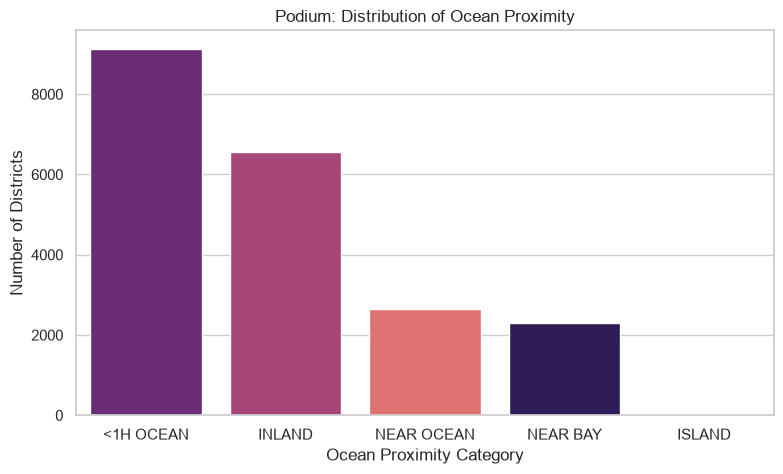

In [37]:
# Extract the categories sorted by their frequency to create the "podium"
podium_order = df['ocean_proximity'].value_counts().index

# Set up the visual space
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Create the count plot (bar plot for categorical data)
sns.countplot(
    data=df, 
    x='ocean_proximity', 
    hue = 'ocean_proximity',
    order=podium_order, 
    palette='magma',
    legend=False
)

# Add titles and labels for clarity
plt.title('Podium: Distribution of Ocean Proximity')
plt.xlabel('Ocean Proximity Category')
plt.ylabel('Number of Districts')

# Display the plot
plt.show()
